# Low-Rank Structure of Animal Pose

This notebook demonstrates that animal pose is inherently low-rank across multiple species and datasets.
We perform SVD on egocentric 3D pose coordinates and show:

1. **Singular value spectrum** — a small number of components captures most variance
2. **Variance Accounted For (VAF)** — cumulative and per-frame, showing high reconstruction quality at low rank
3. **Worst frames by rank-5 error** — deviations from the low-rank model identify challenging/unusual poses

Datasets: **chickadee-crop**, **fly-anipose**, **two-mouse**, **ibl-mouse**  
Model: **Non-linear EKS with variance inflation** (single model, no cross-model comparison)

## 1. Imports and Setup

In [22]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from omegaconf import OmegaConf
from lightning_pose.data.cameras import CameraGroup
from lp3d_analysis.dataset_info import dataset_info

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

## 2. Utility Functions

In [23]:
def load_2d_predictions(csv_dir, views, csv_name_fn):
    """Load 2D predictions for all views.

    Parameters
    ----------
    csv_dir : str
        Directory containing CSV files.
    views : list of str
        Camera view names.
    csv_name_fn : callable
        Function(view) -> csv filename.

    Returns
    -------
    dict : view -> {'xs', 'ys', 'ls', 'marker_names'}
    """
    all_data = {}
    for view in views:
        csv_path = os.path.join(csv_dir, csv_name_fn(view))
        df = pd.read_csv(csv_path, header=[0, 1, 2], index_col=0)
        marker_names = df.columns.get_level_values(1).unique()
        xs = df.loc[:, df.columns.get_level_values(2).isin(['x'])].to_numpy()
        ys = df.loc[:, df.columns.get_level_values(2).isin(['y'])].to_numpy()
        ls = df.loc[:, df.columns.get_level_values(2).isin(['likelihood'])].to_numpy()
        all_data[view] = {
            'xs': xs, 'ys': ys, 'ls': ls, 'marker_names': list(marker_names)
        }
    return all_data


def triangulate_session(csv_dir, views, csv_name_fn, calib_path, n_keypoints):
    """Load 2D predictions, triangulate to 3D.

    Returns
    -------
    pts_3d : (n_frames, n_keypoints, 3)
    camgroup : CameraGroup
    """
    camgroup = CameraGroup.load(calib_path)
    calib_cam_names = [c.name for c in camgroup.cameras]

    preds_2d = load_2d_predictions(csv_dir, views, csv_name_fn)
    n_frames = preds_2d[views[0]]['xs'].shape[0]

    n_cams = len(calib_cam_names)
    pts_2d = np.zeros((n_cams, n_frames, n_keypoints, 2))
    for cam_idx, cam_name in enumerate(calib_cam_names):
        pts_2d[cam_idx, :, :, 0] = preds_2d[cam_name]['xs'][:n_frames]
        pts_2d[cam_idx, :, :, 1] = preds_2d[cam_name]['ys'][:n_frames]

    pts_3d = np.zeros((n_frames, n_keypoints, 3))
    for t in range(n_frames):
        pts_3d[t] = camgroup.triangulate_fast(pts_2d[:, t, :, :], undistort=True)
        if t % 500 == 0:
            print(f"  Triangulated frame {t}/{n_frames}")
    print(f"  3D shape: {pts_3d.shape}, NaN frames: {np.isnan(pts_3d).any(axis=(1,2)).sum()}")
    return pts_3d, camgroup


def to_egocentric(points_3d, keypoint_names, center_kp, head_kp, tail_kp):
    """Convert 3D points to egocentric coordinates.

    1. Center on `center_kp`
    2. Rotate so head_kp->tail_kp axis aligns with +X in the horizontal plane
    """
    n_frames, n_kp, _ = points_3d.shape
    center_idx = keypoint_names.index(center_kp)
    head_idx = keypoint_names.index(head_kp)
    tail_idx = keypoint_names.index(tail_kp)

    points_ego = np.zeros_like(points_3d)

    for t in range(n_frames):
        origin = points_3d[t, center_idx, :]
        centered = points_3d[t] - origin

        fwd = centered[head_idx] - centered[tail_idx]
        fwd_xy = fwd[:2]
        norm_xy = np.linalg.norm(fwd_xy)

        if norm_xy < 1e-8:
            points_ego[t] = centered
            continue

        fwd_xy = fwd_xy / norm_xy
        cos_a, sin_a = fwd_xy[0], fwd_xy[1]
        R_2d = np.array([[cos_a, sin_a], [-sin_a, cos_a]])

        rotated = centered.copy()
        rotated[:, :2] = (R_2d @ centered[:, :2].T).T
        points_ego[t] = rotated

    return points_ego


def compute_svd_analysis(points_3d):
    """Compute SVD on pose matrix (n_frames, n_keypoints, 3).

    Returns
    -------
    U, S, Vt, data_centered, valid_mask, mean
    """
    n_frames = points_3d.shape[0]
    data = points_3d.reshape(n_frames, -1)
    valid_mask = ~np.isnan(data).any(axis=1)
    data_valid = data[valid_mask]
    print(f"  Valid frames for SVD: {data_valid.shape[0]} / {n_frames}")

    mean = np.mean(data_valid, axis=0)
    data_centered = data_valid - mean
    U, S, Vt = np.linalg.svd(data_centered, full_matrices=False)

    return U, S, Vt, data_centered, valid_mask, mean


def compute_per_frame_vaf(U, S, Vt, data_centered, ranks=[3, 4, 5]):
    """Compute per-frame VAF for multiple ranks."""
    per_frame_vaf = {}
    for rank in ranks:
        X_k = U[:, :rank] @ np.diag(S[:rank]) @ Vt[:rank, :]
        residual = np.sum((data_centered - X_k) ** 2, axis=1)
        total_var = np.sum(data_centered ** 2, axis=1)
        per_frame_vaf[rank] = 1.0 - residual / (total_var + 1e-12)
    return per_frame_vaf


def get_worst_frames(per_frame_vaf, valid_mask, n_frames, rank=5, n_worst=50):
    """Find the worst frames by rank-k reconstruction error."""
    vaf = per_frame_vaf[rank]
    vaf_full = np.full(n_frames, np.nan)
    vaf_full[valid_mask] = vaf
    error_full = 1.0 - vaf_full

    valid_indices = np.where(~np.isnan(error_full))[0]
    sorted_by_error = valid_indices[np.argsort(error_full[valid_indices])[::-1]]
    worst_idxs = sorted_by_error[:n_worst]
    return np.sort(worst_idxs), vaf_full, error_full

## 3. Dataset Configurations

Each dataset entry specifies:
- Path to the non-linear EKS + variance inflation CSV directory
- Session name(s) to analyze
- Camera views and keypoint info
- Egocentric alignment keypoints (if applicable)
- How to construct CSV filenames from view names

In [24]:
DATASETS = {
    'chickadee-crop': {
        'csv_dir': (
            '/teamspace/studios/this_studio/outputs/chickadee-crop/'
            'test_200_MVT_3d_loss_patch_masking_new/mvt_3d_loss_200_0-2/'
            'non_linear_eks_varinf/videos_new_fix'
        ),
        'data_dir': '/teamspace/studios/data/chickadee-crop',
        'config_file': '/teamspace/studios/this_studio/lp3d-analysis/configs/config_chickadee-crop.yaml',
        'sessions': ['PRL43_200701_142147'],
        'views': ['lBack', 'lFront', 'lTop', 'rBack', 'rFront', 'rTop'],
        'csv_name_fn': lambda session: lambda view: f'{session}_{view}.short_uncropped.csv',
        'calib_fn': lambda data_dir, session: os.path.join(data_dir, 'calibrations', f'{session}.toml'),
        'egocentric': {
            'center_kp': 'centerBack',
            'head_kp': 'backHead',
            'tail_kp': 'baseTail',
        },
        'display_name': 'Chickadee',
        'color': 'steelblue',
    },
    'fly-anipose': {
        'csv_dir': (
            '/teamspace/studios/this_studio/outputs/fly-anipose/'
            'test_200_MVT_3d_loss_patch_masking/mvt_3d_loss_200_0-2/'
            'ensemble_median/videos_new'
        ),
        'data_dir': '/teamspace/studios/data/fly-anipose',
        'config_file': '/teamspace/studios/this_studio/lp3d-analysis/configs/config_fly-anipose.yaml',
        'sessions': ['05272019_fly4_0_R2C14_str-ccw-0.72_sec'],
        'views': ['Cam-A', 'Cam-B', 'Cam-C', 'Cam-D', 'Cam-E', 'Cam-F'],
        'csv_name_fn': lambda session: lambda view, s=session: f"{'_'.join(s.split('_')[:4])}_{view}_{'_'.join(s.split('_')[4:])}.csv",
        'calib_fn': lambda data_dir, session: os.path.join(data_dir, 'calibrations', f'{session}.toml'),
        'egocentric': None,
        'display_name': 'Fly',
        'color': 'coral',
    },
    'two-mouse': {
        'csv_dir': (
            '/teamspace/studios/this_studio/outputs/two-mouse/'
            'test_100_MVT_3d_loss_patch_masking/mvt_3d_loss_100_0-2/'
            'non_linear_eks_varinf/videos_new'
        ),
        'data_dir': '/teamspace/studios/data/two-mouse',
        'config_file': '/teamspace/studios/this_studio/lp3d-analysis/configs/config_two-mouse.yaml',
        'sessions': ['CSDS-Day5-A_11-Defeat'],
        'views': ['Camera0', 'Camera1', 'Camera2', 'Camera3', 'Camera4'],
        'csv_name_fn': lambda session: lambda view: f'{session}_{view}.csv',
        'calib_fn': lambda data_dir, session: os.path.join(data_dir, 'calibrations', f'{session}.toml'),
        # 'egocentric': None,
        'egocentric': {
            'center_kp': 'Trunk_black',
            'head_kp': 'Nose_black',
            'tail_kp': 'TTI_black',
        },
        'display_name': 'Two-Mouse',
        'color': 'limegreen',
    },
    'ibl-mouse': {
        'csv_dir': (
            '/teamspace/studios/this_studio/outputs/ibl-mouse/'
            'test_200_MVT_3d_loss_patch_masking/mvt_3d_loss_200_0-2/'
            'non_linear_eks_varinf/videos_new'
        ),
        'data_dir': '/teamspace/studios/data/ibl-mouse',
        'config_file': '/teamspace/studios/this_studio/lp3d-analysis/configs/config_ibl-mouse.yaml',
        'sessions': ['0841d188-8ef2-4f20-9828-76a94d5343a4'],
        'views': ['rightCamera', 'leftCamera'],
        'csv_name_fn': lambda session: lambda view: f'_iblrig_{view}.downsampled.{session}.csv',
        'calib_fn': lambda data_dir, session: os.path.join(
            data_dir, 'calibrations', f'_iblrig.downsampled.{session}.toml'
        ),
        'egocentric': None,
        'display_name': 'IBL Mouse',
        'color': 'orchid',
    },
}

print(f"Configured {len(DATASETS)} datasets: {list(DATASETS.keys())}")
save_path = "/teamspace/studios/this_studio/figures"

Configured 4 datasets: ['chickadee-crop', 'fly-anipose', 'two-mouse', 'ibl-mouse']


## 4. Run Full Pipeline for All Datasets

For each dataset and session:
1. Load 2D predictions → triangulate to 3D
2. (Optional) Convert to egocentric coordinates
3. Compute SVD
4. Compute per-frame VAF at ranks 3, 4, 5

In [25]:
all_results = {}  # dataset_name -> session_name -> results dict

for ds_name, ds_cfg in DATASETS.items():
    print(f"\n{'='*70}")
    print(f"  DATASET: {ds_name}")
    print(f"{'='*70}")

    cfg = OmegaConf.load(ds_cfg['config_file'])
    keypoint_names = list(cfg.data.keypoint_names)
    n_keypoints = len(keypoint_names)

    all_results[ds_name] = {}

    for session in ds_cfg['sessions']:
        print(f"\n--- Session: {session} ---")

        csv_name_fn = ds_cfg['csv_name_fn'](session)
        calib_path = ds_cfg['calib_fn'](ds_cfg['data_dir'], session)
        print(f"  Calibration: {calib_path}")

        pts_3d, camgroup = triangulate_session(
            ds_cfg['csv_dir'], ds_cfg['views'], csv_name_fn,
            calib_path, n_keypoints,
        )

        if ds_cfg['egocentric'] is not None:
            ego_cfg = ds_cfg['egocentric']
            pts_for_svd = to_egocentric(
                pts_3d, keypoint_names,
                center_kp=ego_cfg['center_kp'],
                head_kp=ego_cfg['head_kp'],
                tail_kp=ego_cfg['tail_kp'],
            )
            print(f"  Using egocentric coordinates")
        else:
            pts_for_svd = pts_3d
            print(f"  Using raw 3D coordinates (no egocentric alignment)")

        U, S, Vt, data_centered, valid_mask, mean = compute_svd_analysis(pts_for_svd)
        var_explained = (S ** 2) / np.sum(S ** 2) * 100
        cum_var = np.cumsum(var_explained)
        per_frame_vaf = compute_per_frame_vaf(U, S, Vt, data_centered)

        n_95 = np.argmax(cum_var >= 95) + 1
        n_99 = np.argmax(cum_var >= 99) + 1
        print(f"  Top 5 singular values: {S[:5].round(4)}")
        print(f"  Components for 95% var: {n_95}")
        print(f"  Components for 99% var: {n_99}")

        all_results[ds_name][session] = {
            'points_3d': pts_3d,
            'points_for_svd': pts_for_svd,
            'U': U, 'S': S, 'Vt': Vt,
            'data_centered': data_centered,
            'valid_mask': valid_mask,
            'mean': mean,
            'var_explained': var_explained,
            'cum_var': cum_var,
            'per_frame_vaf': per_frame_vaf,
            'n_frames': pts_3d.shape[0],
            'keypoint_names': keypoint_names,
            'n_keypoints': n_keypoints,
        }

print(f"\nDone. Processed {sum(len(v) for v in all_results.values())} sessions across {len(all_results)} datasets.")


  DATASET: chickadee-crop

--- Session: PRL43_200701_142147 ---
  Calibration: /teamspace/studios/data/chickadee-crop/calibrations/PRL43_200701_142147.toml


  Triangulated frame 0/1800
  Triangulated frame 500/1800
  Triangulated frame 1000/1800
  Triangulated frame 1500/1800
  3D shape: (1800, 18, 3), NaN frames: 0
  Using egocentric coordinates
  Valid frames for SVD: 1800 / 1800
  Top 5 singular values: [3.1518 3.1035 1.3712 1.1032 0.9821]
  Components for 95% var: 7
  Components for 99% var: 19

  DATASET: fly-anipose

--- Session: 05272019_fly4_0_R2C14_str-ccw-0.72_sec ---
  Calibration: /teamspace/studios/data/fly-anipose/calibrations/05272019_fly4_0_R2C14_str-ccw-0.72_sec.toml
  Triangulated frame 0/601
  Triangulated frame 500/601
  3D shape: (601, 30, 3), NaN frames: 0
  Using raw 3D coordinates (no egocentric alignment)
  Valid frames for SVD: 601 / 601
  Top 5 singular values: [4.3708 3.7386 3.0333 2.5619 2.3283]
  Components for 95% var: 14
  Components for 99% var: 27

  DATASET: two-mouse

--- Session: CSDS-Day5-A_11-Defeat ---
  Calibration: /teamspace/studios/data/two-mouse/calibrations/CSDS-Day5-A_11-Defeat.toml
  Triangul

## 5. Summary Figure: Animals Are Low-Rank

A single multi-panel figure showing the singular value spectrum and cumulative VAF for all four datasets,
demonstrating that a small number of components captures the vast majority of pose variance.

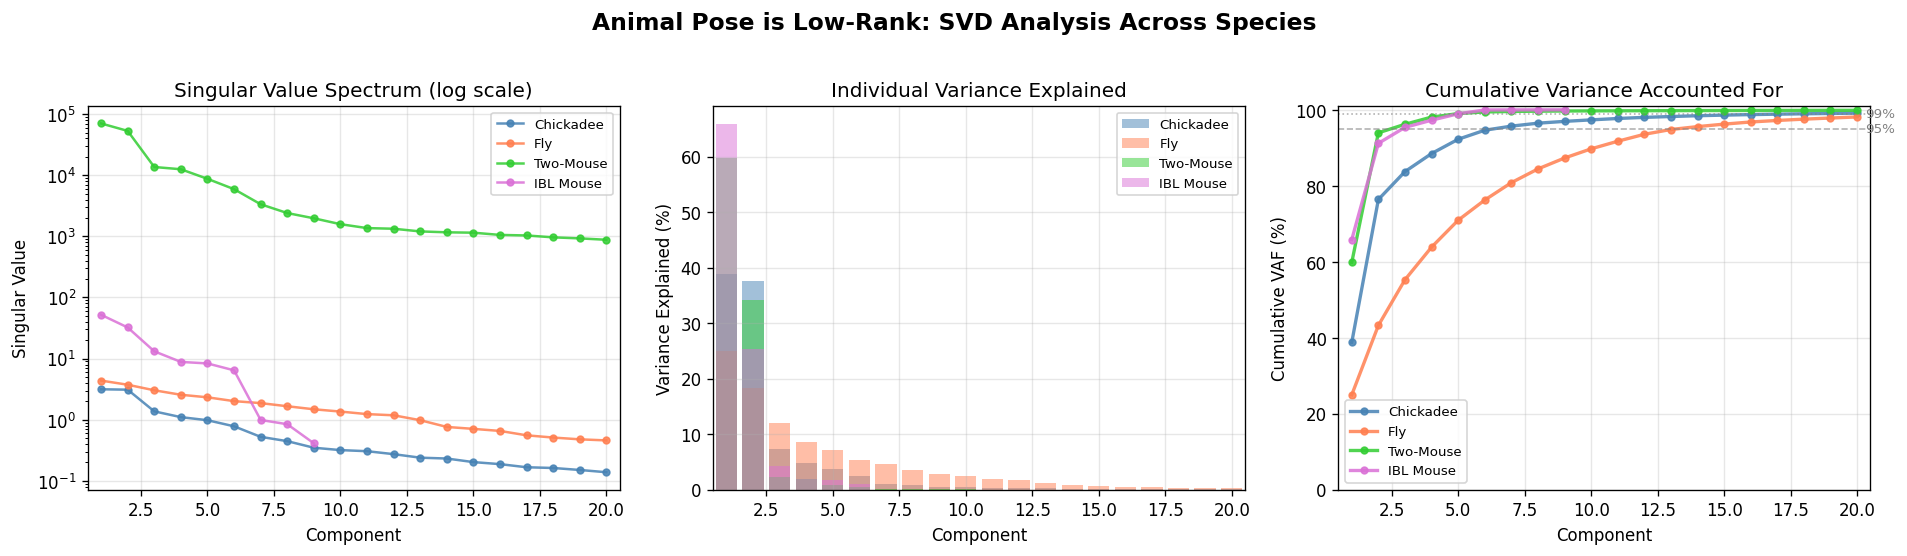


Dataset              Keypoints    Dims (K×3)   95% VAF    99% VAF   
----------------------------------------------------------------
Chickadee            18           54           7          19        
Fly                  30           90           14         27        
Two-Mouse            22           66           3          5         
IBL Mouse            3            9            3          6         


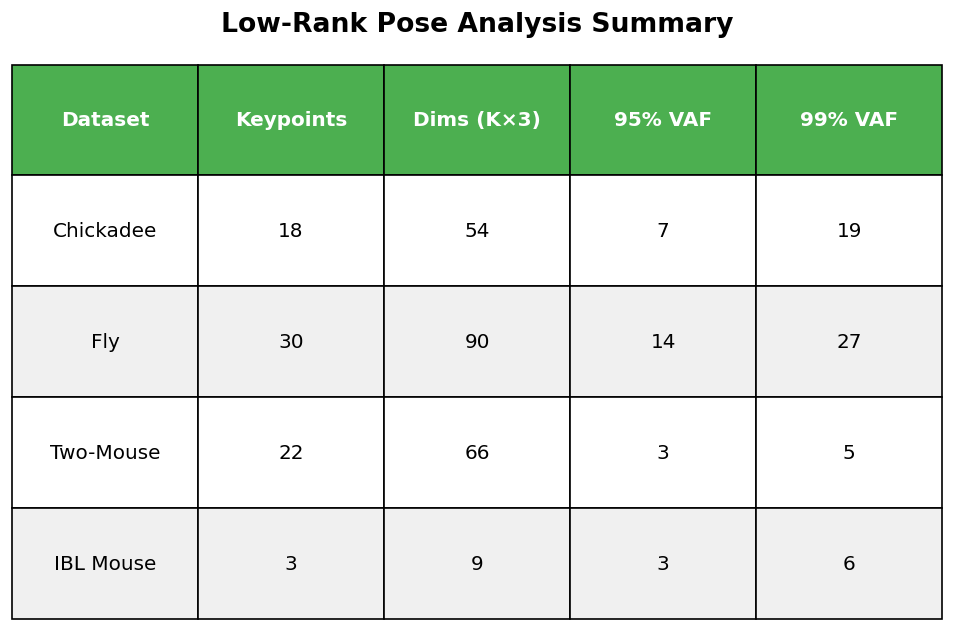

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

max_comp = 20

for ds_name, ds_cfg in DATASETS.items():
    color = ds_cfg['color']
    label = ds_cfg['display_name']
    for session, r in all_results[ds_name].items():
        n_show = min(len(r['S']), max_comp)

        # Panel 1: Singular values (log scale)
        axes[0].semilogy(
            range(1, n_show + 1), r['S'][:n_show],
            'o-', color=color, markersize=4, linewidth=1.5, label=label, alpha=0.85,
        )

        # Panel 2: Individual variance explained
        axes[1].bar(
            np.arange(1, n_show + 1), r['var_explained'][:n_show],
            color=color, alpha=0.5, label=label, width=0.8,
        )

        # Panel 3: Cumulative VAF
        axes[2].plot(
            range(1, n_show + 1), r['cum_var'][:n_show],
            'o-', color=color, markersize=4, linewidth=2, label=label, alpha=0.85,
        )

# Panel 1 formatting
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Singular Value')
axes[0].set_title('Singular Value Spectrum (log scale)')
axes[0].legend(fontsize=8)
axes[0].set_xlim(0.5, max_comp + 0.5)
axes[0].grid(True, alpha=0.3)

# Panel 2 formatting
axes[1].set_xlabel('Component')
axes[1].set_ylabel('Variance Explained (%)')
axes[1].set_title('Individual Variance Explained')
axes[1].legend(fontsize=8)
axes[1].set_xlim(0.5, max_comp + 0.5)
axes[1].grid(True, alpha=0.3)

# Panel 3 formatting
axes[2].axhline(y=95, color='gray', linestyle='--', alpha=0.6, linewidth=1)
axes[2].axhline(y=99, color='gray', linestyle=':', alpha=0.6, linewidth=1)
axes[2].text(max_comp + 0.3, 95, '95%', va='center', fontsize=8, color='gray')
axes[2].text(max_comp + 0.3, 99, '99%', va='center', fontsize=8, color='gray')
axes[2].set_xlabel('Component')
axes[2].set_ylabel('Cumulative VAF (%)')
axes[2].set_title('Cumulative Variance Accounted For')
axes[2].legend(fontsize=8)
axes[2].set_xlim(0.5, max_comp + 0.5)
axes[2].set_ylim(0, 101)
axes[2].grid(True, alpha=0.3)

plt.suptitle(
    'Animal Pose is Low-Rank: SVD Analysis Across Species',
    fontsize=14, fontweight='bold', y=1.02,
)
plt.tight_layout()
# plt.savefig('low_rank_summary.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Print summary table
# Create summary table data
table_data = []
headers = ['Dataset', 'Keypoints', 'Dims (K×3)', '95% VAF', '99% VAF']

for ds_name in DATASETS:
    for session, r in all_results[ds_name].items():
        n_kp = r['n_keypoints']
        n_95 = np.argmax(r['cum_var'] >= 95) + 1
        n_99 = np.argmax(r['cum_var'] >= 99) + 1
        table_data.append([
            DATASETS[ds_name]['display_name'],
            str(n_kp),
            str(n_kp*3),
            str(n_95),
            str(n_99)
        ])

# Print to console
print(f"\n{'Dataset':<20} {'Keypoints':<12} {'Dims (K×3)':<12} {'95% VAF':<10} {'99% VAF':<10}")
print('-' * 64)
for row in table_data:
    print(f"{row[0]:<20} {row[1]:<12} {row[2]:<12} {row[3]:<10} {row[4]:<10}")

# Create table figure for PDF export
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('tight')
ax.axis('off')

# Create table
table = ax.table(
    cellText=table_data,
    colLabels=headers,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)

# Style header row
for i in range(len(headers)):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style data rows with alternating colors
for i in range(1, len(table_data) + 1):
    for j in range(len(headers)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
        else:
            table[(i, j)].set_facecolor('white')

plt.title('Low-Rank Pose Analysis Summary', fontsize=16, fontweight='bold', pad=20)
plt.savefig(f'{save_path}/low_rank_summary_table.pdf', bbox_inches='tight', dpi=300)
plt.show()

## 6. Per-Dataset Analysis: VAF Traces and Worst Frames

For each dataset we show:
- Per-frame VAF at rank 5 over time
- The 50 worst frames highlighted — these correspond to unusual/challenging poses

**Key insight**: Deviations from the low-rank model are not noise — they identify frames where the animal is in a rare or complex pose, making them useful for active learning or quality control.

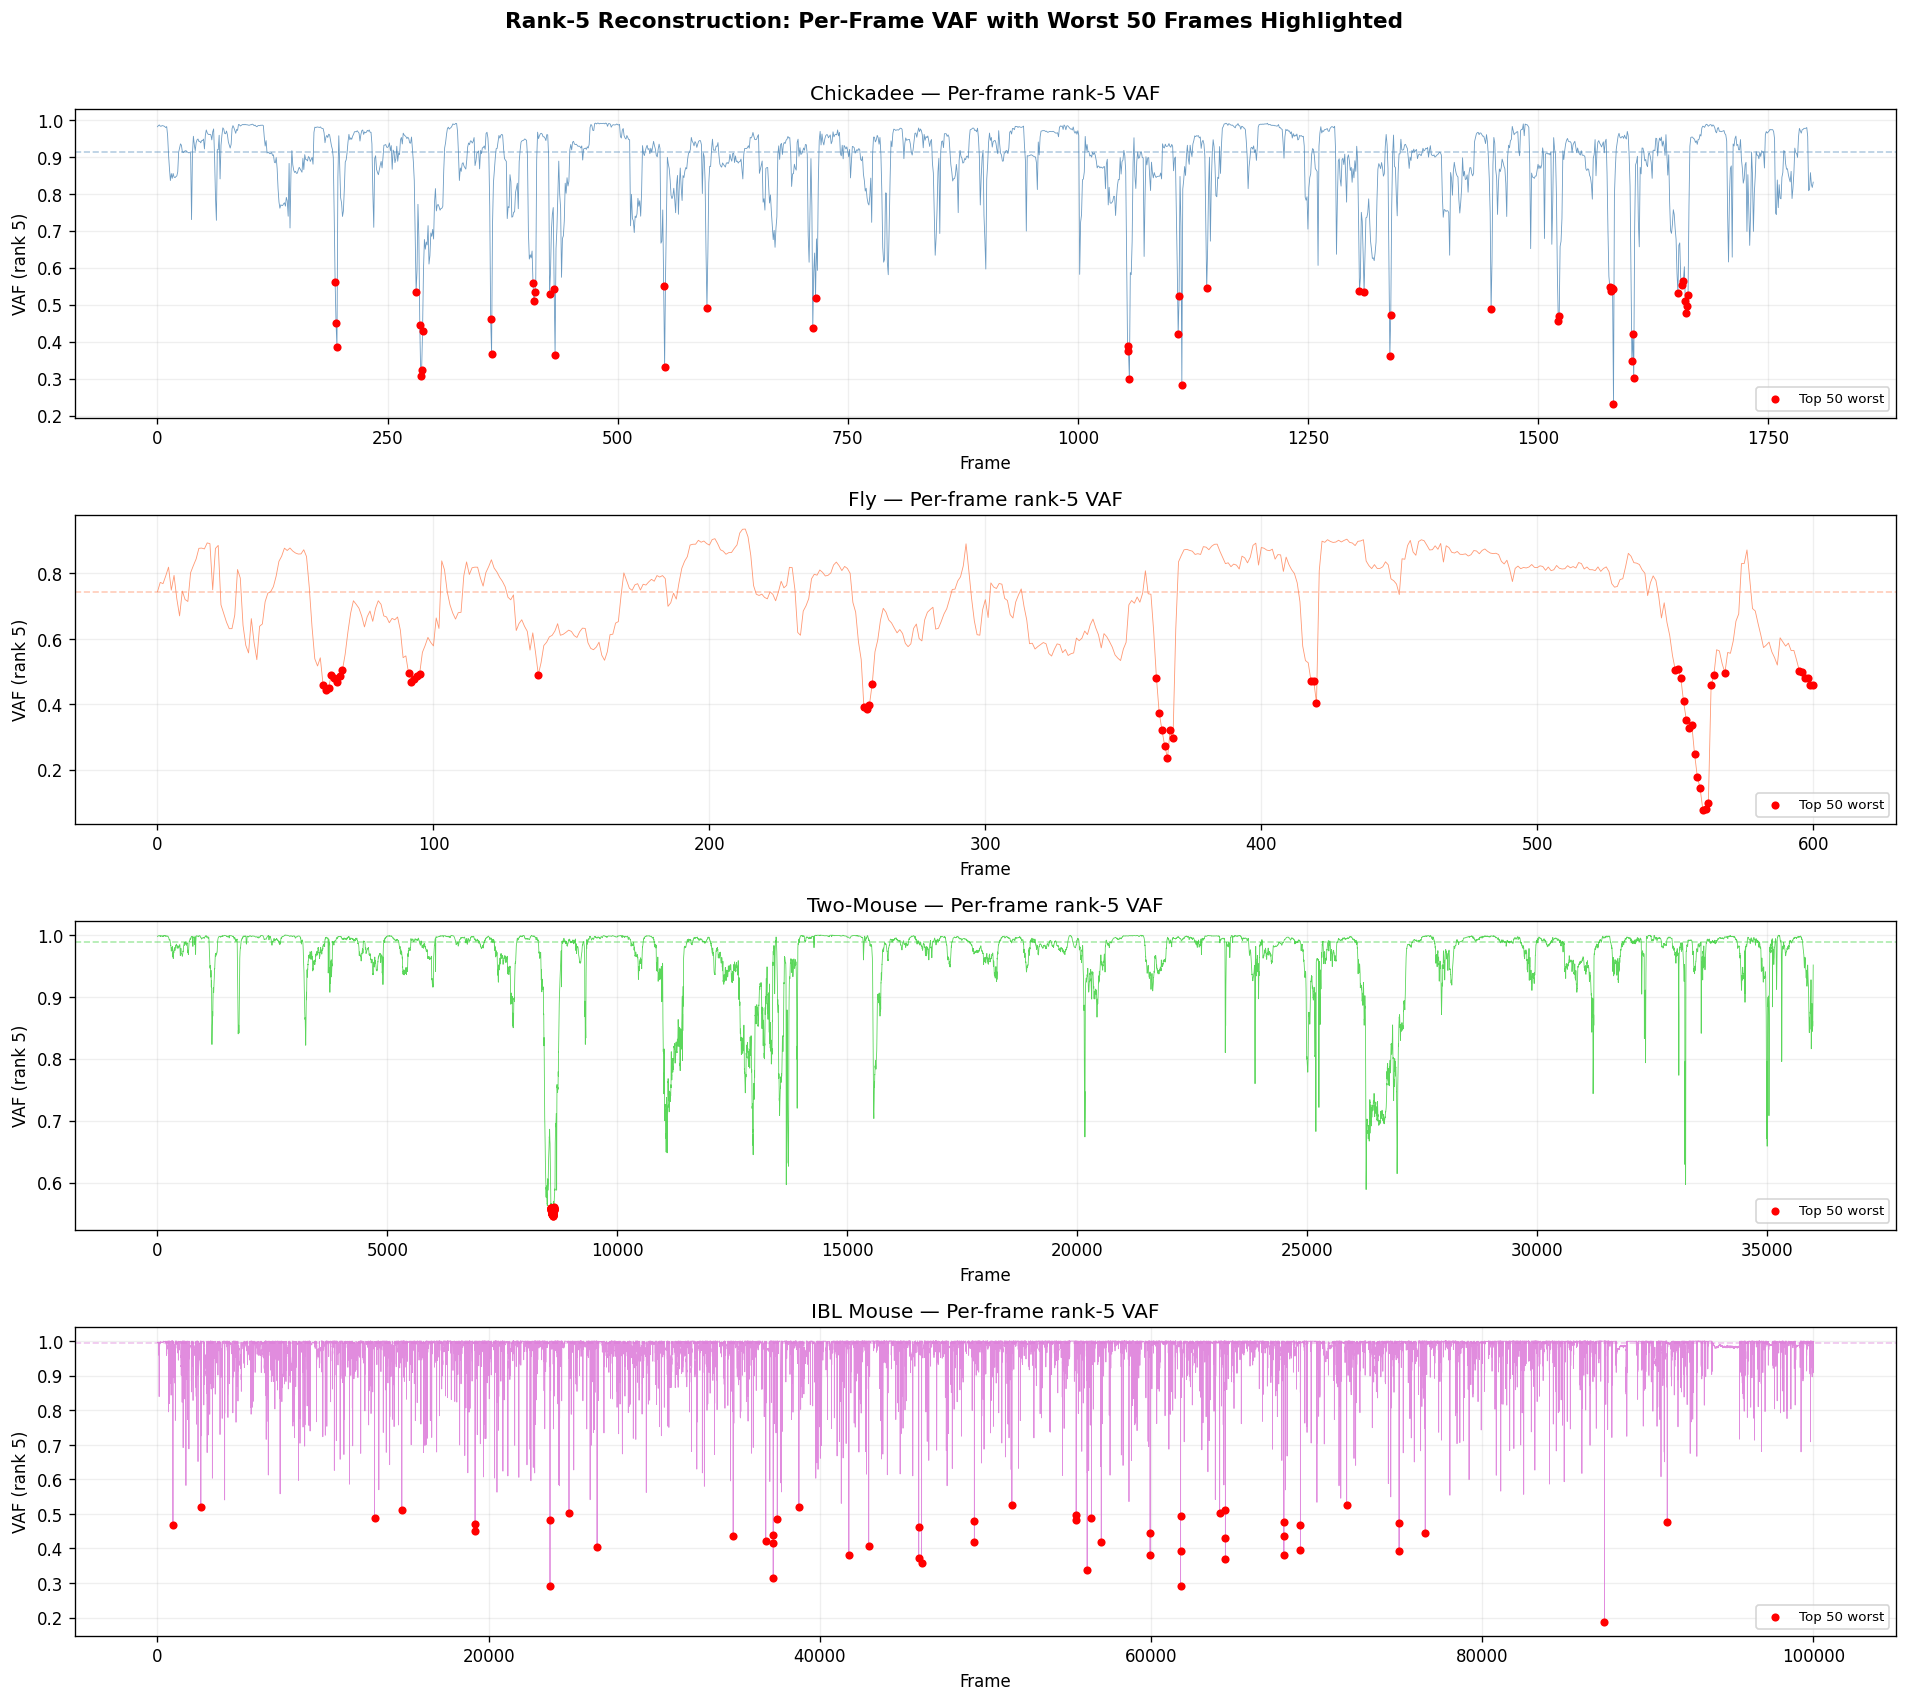

In [27]:
INSPECT_RANK = 5
N_WORST = 50

n_datasets = len(DATASETS)
fig, axes = plt.subplots(n_datasets, 1, figsize=(16, 3.5 * n_datasets))
if n_datasets == 1:
    axes = [axes]

worst_frames_all = {}

for ax, (ds_name, ds_cfg) in zip(axes, DATASETS.items()):
    color = ds_cfg['color']
    label = ds_cfg['display_name']

    for session, r in all_results[ds_name].items():
        worst_idxs, vaf_full, error_full = get_worst_frames(
            r['per_frame_vaf'], r['valid_mask'], r['n_frames'],
            rank=INSPECT_RANK, n_worst=N_WORST,
        )
        worst_frames_all[(ds_name, session)] = worst_idxs

        ax.plot(vaf_full, linewidth=0.5, color=color, alpha=0.8)
        ax.scatter(
            worst_idxs, vaf_full[worst_idxs],
            c='red', s=15, zorder=5, label=f'Top {N_WORST} worst',
        )

        median_vaf = np.nanmedian(vaf_full)
        worst_vaf = vaf_full[worst_idxs].min()
        ax.axhline(y=median_vaf, color=color, linestyle='--', alpha=0.4, linewidth=1)

    ax.set_xlabel('Frame')
    ax.set_ylabel(f'VAF (rank {INSPECT_RANK})')
    ax.set_title(f'{label} — Per-frame rank-{INSPECT_RANK} VAF')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.2)

plt.suptitle(
    f'Rank-{INSPECT_RANK} Reconstruction: Per-Frame VAF with Worst {N_WORST} Frames Highlighted',
    fontsize=13, fontweight='bold', y=1.01,
)
plt.tight_layout()
plt.savefig(f'{save_path}/worst_frames_vaf.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [30]:
# Print worst-frame statistics for each dataset
print(f"{'Dataset':<20} {'Session':<50} {'Median VAF':<12} {'Worst VAF':<12} {'Mean worst error':<16}")
print('-' * 110)

for (ds_name, session), worst_idxs in worst_frames_all.items():
    r = all_results[ds_name][session]
    vaf = r['per_frame_vaf'][INSPECT_RANK]
    vaf_full = np.full(r['n_frames'], np.nan)
    vaf_full[r['valid_mask']] = vaf

    median_vaf = np.nanmedian(vaf_full)
    worst_vaf = vaf_full[worst_idxs].min()
    mean_worst_error = (1.0 - vaf_full[worst_idxs]).mean()

    print(
        f"{DATASETS[ds_name]['display_name']:<20} "
        f"{session:<50} "
        f"{median_vaf:<12.4f} "
        f"{worst_vaf:<12.4f} "
        f"{mean_worst_error:<16.4f}"
    )

print(f"\nWorst frame indices per dataset:")
for (ds_name, session), worst_idxs in worst_frames_all.items():
    print(f"  {DATASETS[ds_name]['display_name']} ({session}):")
    print(f"    {worst_idxs}")

Dataset              Session                                            Median VAF   Worst VAF    Mean worst error
--------------------------------------------------------------------------------------------------------------
Chickadee            PRL43_200701_142147                                0.9129       0.2324       0.5416          
Fly                  05272019_fly4_0_R2C14_str-ccw-0.72_sec             0.7444       0.0772       0.5993          
Two-Mouse            CSDS-Day5-A_11-Defeat                              0.9881       0.5465       0.4470          
IBL Mouse            0841d188-8ef2-4f20-9828-76a94d5343a4               0.9949       0.1885       0.5655          

Worst frame indices per dataset:
  Chickadee (PRL43_200701_142147):
    [ 193  194  195  281  285  286  287  288  362  363  408  409  410  426
  431  432  550  551  597  712  715 1054 1055 1056 1109 1110 1113 1140
 1306 1311 1339 1340 1449 1522 1523 1578 1579 1580 1581 1582 1602 1603
 1604 1652 1656 1657 1660 16

## 7. Per-Frame VAF Distribution (Histograms)

Histograms of per-frame VAF at rank 5 for each dataset, showing that the vast majority of frames
are well-explained by a rank-5 model, with a small tail of challenging frames.

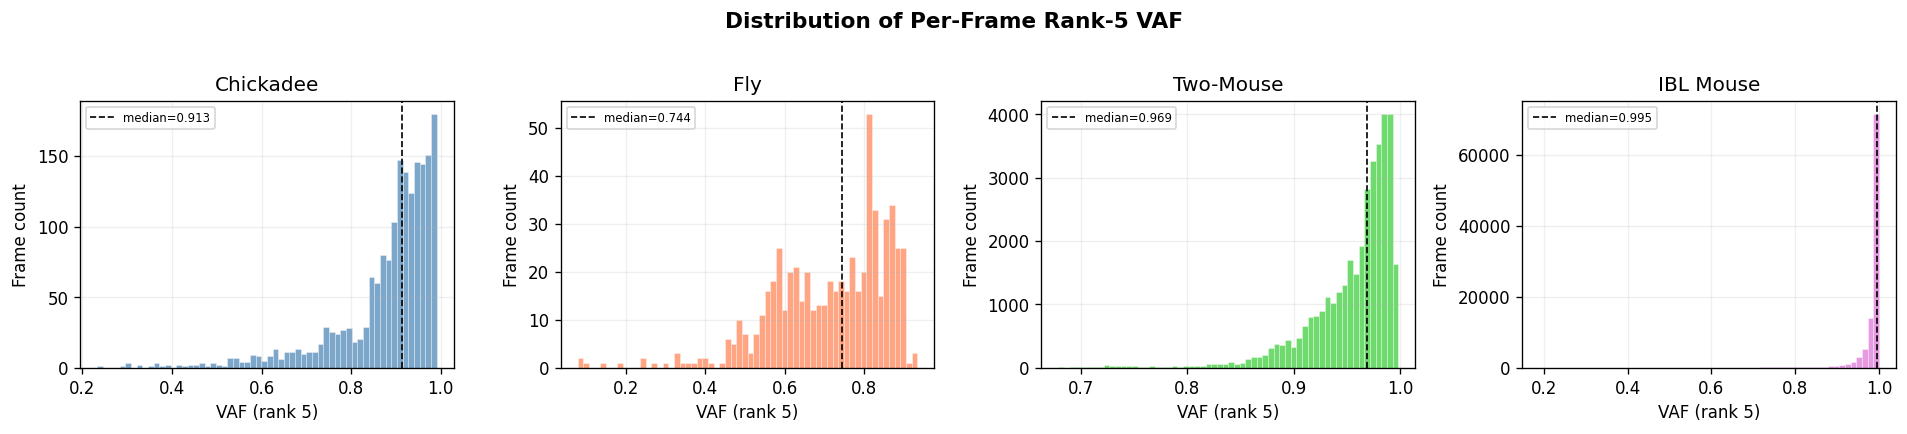

In [ ]:
fig, axes = plt.subplots(1, n_datasets, figsize=(4 * n_datasets, 3.5))
if n_datasets == 1:
    axes = [axes]

for ax, (ds_name, ds_cfg) in zip(axes, DATASETS.items()):
    for session, r in all_results[ds_name].items():
        vaf = r['per_frame_vaf'][INSPECT_RANK]
        ax.hist(vaf, bins=60, color=ds_cfg['color'], alpha=0.7, edgecolor='white', linewidth=0.3)
        ax.axvline(np.median(vaf), color='black', linestyle='--', linewidth=1, label=f'median={np.median(vaf):.3f}')

    ax.set_xlabel(f'VAF (rank {INSPECT_RANK})')
    ax.set_ylabel('Frame count')
    ax.set_title(ds_cfg['display_name'])
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)

plt.suptitle(
    f'Distribution of Per-Frame Rank-{INSPECT_RANK} VAF',
    fontsize=13, fontweight='bold', y=1.02,
)
plt.tight_layout()
# plt.savefig('vaf_histograms.pdf', bbox_inches='tight', dpi=300)
plt.show()

## 8. Combined Summary: Cumulative VAF Across All Datasets

A single clean figure for the paper showing cumulative VAF curves overlaid for all four species.

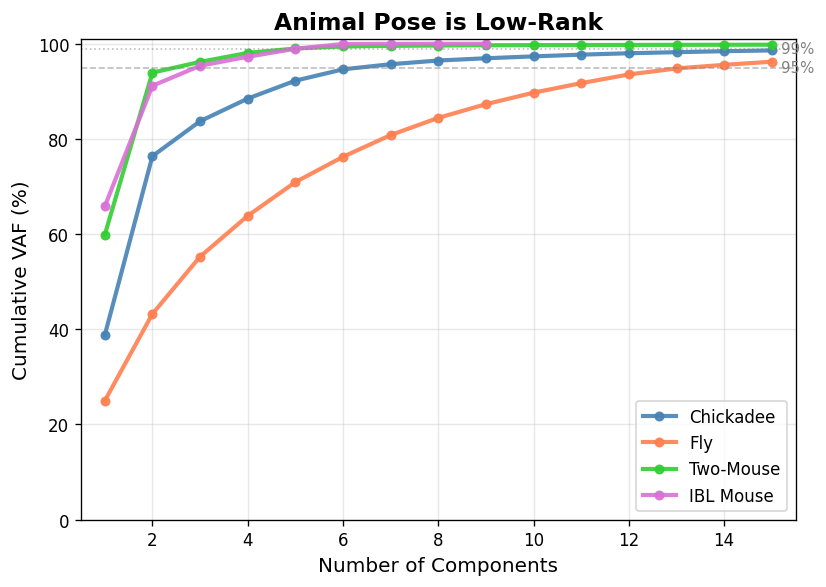

In [29]:
fig, ax = plt.subplots(figsize=(7, 5))

for ds_name, ds_cfg in DATASETS.items():
    color = ds_cfg['color']
    for session, r in all_results[ds_name].items():
        total_dims = r['n_keypoints'] * 3
        n_components = len(r['cum_var'])
        frac_pcs = np.arange(1, n_components + 1) / total_dims
        cum_vaf_frac = r['cum_var'] / 100.0
        label = f"{ds_cfg['display_name']} ({total_dims}D)"
        ax.plot(
            frac_pcs, cum_vaf_frac,
            'o-', color=color, markersize=4, linewidth=2.5, label=label, alpha=0.9,
        )

ax.axhline(y=0.99, color='k', linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(1.02, 0.99, '0.99', va='center', fontsize=10, color='k', fontweight='bold')

ax.set_xlabel('Fraction of PCs kept', fontsize=12)
ax.set_ylabel('Cumulative VAF', fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(0, 1.0)
ax.set_ylim(0.3, 1.02)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{save_path}/cumulative_vaf_all_datasets.pdf', bbox_inches='tight', dpi=300)
plt.show()

## 9. 3D Skeleton Video with VAF Traces

Render a video showing the 3D skeleton (egocentric or raw) on top, with per-frame rank-k VAF
traces growing below. The traces show how well the low-rank model explains each frame over time.

**Key parameters:**
- `DATASET_KEY` / `SESSION_KEY` — which dataset/session to render
- `START_FRAME` — first frame of the video (pick any frame to start from)
- `MAX_FRAMES` — how many frames to render (set `None` for all)
- `RANKS_TO_PLOT` — which rank VAF traces to show below the skeleton
- `GENERATE_VIDEO` — set to `True` to actually render (can be slow)

In [11]:
import shutil
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from lp3d_analysis.video import save_video
from lp3d_analysis.dataset_info import dataset_info as ds_info_dict


def make_skeleton_video_with_vaf(
    save_file,
    result,
    dataset_key,
    ranks_to_plot=[5],
    start_frame=0,
    max_frames=None,
    framerate=20,
    elev=25,
    azim=-60,
    figsize=(12, 10),
    invert_z=False,
):
    """Render 3D skeleton video with growing VAF traces below.

    Parameters
    ----------
    save_file : str
        Output .mp4 path.
    result : dict
        Single session result from all_results[ds][session].
    dataset_key : str
        Key into DATASETS / dataset_info (e.g. 'chickadee-crop').
        Used for skeleton connectivity and colors.
    ranks_to_plot : list of int
        Which rank VAF traces to show.
    start_frame : int
        First frame index to include in the video.
    max_frames : int or None
        Number of frames to render starting from start_frame.
        None = render to the end.
    framerate : int
    elev, azim : float
        3D view angles.
    figsize : tuple
    invert_z : bool
    """
    matplotlib.use('Agg')

    pts_for_svd = result['points_for_svd']
    n_frames_total = result['n_frames']
    keypoint_names = result['keypoint_names']

    ds_key_lookup = dataset_key.replace('-crop', '') if dataset_key.endswith('-crop') else dataset_key
    ds_info = ds_info_dict.get(ds_key_lookup, ds_info_dict.get(dataset_key, {}))
    skeleton = ds_info.get('skeleton', np.array([]))
    skeleton_colors = ds_info.get('skeleton_colors', [])

    skeleton_idx = [(int(pair[0]), int(pair[1])) for pair in skeleton]

    end_frame = n_frames_total
    if max_frames is not None:
        end_frame = min(start_frame + max_frames, n_frames_total)
    idxs = np.arange(start_frame, end_frame)

    if len(idxs) == 0:
        print("No frames to render.")
        return

    tmp_dir = os.path.join(os.path.dirname(save_file), 'tmpZzZ_skeleton_vaf')
    if os.path.exists(tmp_dir):
        shutil.rmtree(tmp_dir)
    os.makedirs(tmp_dir)

    vaf_traces = {}
    for rank in ranks_to_plot:
        vaf_t = result['per_frame_vaf'][rank]
        vaf_full = np.full(n_frames_total, np.nan)
        vaf_full[result['valid_mask']] = vaf_t
        vaf_traces[rank] = vaf_full

    all_pts = pts_for_svd[~np.isnan(pts_for_svd).any(axis=-1)]
    if len(all_pts) == 0:
        print("All points are NaN — cannot render.")
        return
    pmin = np.percentile(all_pts.reshape(-1, 3), 2, axis=0)
    pmax = np.percentile(all_pts.reshape(-1, 3), 98, axis=0)
    center3d = (pmin + pmax) / 2
    half_range = (pmax - pmin).max() / 2 * 1.2

    n_trace_panels = len(ranks_to_plot)
    height_ratios = [3] + [1] * n_trace_panels

    fig = plt.figure(figsize=figsize)
    gs = GridSpec(1 + n_trace_panels, 1, figure=fig, height_ratios=height_ratios, hspace=0.3)
    ax3d = fig.add_subplot(gs[0], projection='3d')
    ax_traces = [fig.add_subplot(gs[1 + i]) for i in range(n_trace_panels)]

    color = DATASETS[dataset_key]['color']
    display_name = DATASETS[dataset_key]['display_name']

    for fi, frame_idx in enumerate(idxs):
        ax3d.clear()

        pts = pts_for_svd[frame_idx]

        for bi, (i0, i1) in enumerate(skeleton_idx):
            p0, p1 = pts[i0], pts[i1]
            if np.any(np.isnan(p0)) or np.any(np.isnan(p1)):
                continue
            bone_color = skeleton_colors[bi] if bi < len(skeleton_colors) else color
            ax3d.plot(
                [p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]],
                color=bone_color, linewidth=2, alpha=0.8,
            )

        vmask = ~np.isnan(pts).any(axis=1)
        if vmask.any():
            ax3d.scatter(
                pts[vmask, 0], pts[vmask, 1], pts[vmask, 2],
                c='white', edgecolors='black', s=30, zorder=5, depthshade=False,
            )

        ax3d.set_xlim(center3d[0] - half_range, center3d[0] + half_range)
        ax3d.set_ylim(center3d[1] - half_range, center3d[1] + half_range)
        ax3d.set_zlim(center3d[2] - half_range, center3d[2] + half_range)
        if invert_z:
            ax3d.invert_zaxis()
        ax3d.set_xlabel('X', fontsize=8, color='black')
        ax3d.set_ylabel('Y', fontsize=8, color='black')
        ax3d.set_zlabel('Z', fontsize=8, color='black')
        ax3d.view_init(elev=elev, azim=azim)
        ax3d.set_title(f'{display_name} — Frame {frame_idx}', fontsize=10, color='black')
        ax3d.set_facecolor('white')
        ax3d.tick_params(colors='black', labelsize=6)

        for ri, rank in enumerate(ranks_to_plot):
            ax = ax_traces[ri]
            ax.clear()

            trace = vaf_traces[rank]
            ax.plot(
                np.arange(start_frame, frame_idx + 1),
                trace[start_frame:frame_idx + 1],
                color=color, linewidth=1.0, alpha=0.9,
            )

            ax.axvline(x=frame_idx, color='black', linewidth=1.0, alpha=0.6, linestyle=':')

            ax.set_xlim(start_frame, end_frame)
            ax.set_ylim(0, 1.05)
            ax.set_ylabel(f'VAF (rank {rank})', fontsize=8, color='black')
            ax.set_facecolor('white')
            ax.tick_params(colors='black', labelsize=6)
            ax.grid(True, alpha=0.15, color='gray')
            ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.3)

            if ri == n_trace_panels - 1:
                ax.set_xlabel('Frame', fontsize=8, color='black')
            else:
                ax.set_xticklabels([])

        fig.patch.set_facecolor('white')

        # save_path_frame = os.path.join(tmp_dir, f'frame_{fi:06d}.jpeg')
        save_path_frame = os.path.join(tmp_dir, f'frame_{fi:06d}.pdf')
        plt.savefig(save_path_frame, dpi=150, facecolor='white', bbox_inches='tight')

        if fi % 50 == 0:
            print(f"  Rendered frame {fi}/{len(idxs)} (frame_idx={frame_idx})")

    plt.close(fig)
    print(f"Rendered {len(idxs)} frames. Saving video...")
    save_video(save_file, tmp_dir, framerate=framerate)
    shutil.rmtree(tmp_dir)
    print(f"Saved: {save_file}")

print("Video function ready.")

Video function ready.


In [12]:
# ============================================================
# Configure which dataset / session to render
# ============================================================
DATASET_KEY   = 'two-mouse'          # one of: chickadee-crop, fly-anipose, two-mouse, ibl-mouse
SESSION_KEY   = list(all_results[DATASET_KEY].keys())[0]  # first (only) session
RANKS_TO_PLOT = [3, 5]                    # rank VAF traces to draw below skeleton
START_FRAME   = 680                         # pick any frame to start the video
MAX_FRAMES    = 100                      # None = render all remaining frames
FRAMERATE     = 20
GENERATE_VIDEO = True                    # <<< flip to True to actually render

if GENERATE_VIDEO:
    result = all_results[DATASET_KEY][SESSION_KEY]
    out_path = f'/teamspace/studios/this_studio/outputs/{DATASET_KEY}/videos_unlabeled/{DATASET_KEY}_{SESSION_KEY}_skeleton_vaf.mp4'
    make_skeleton_video_with_vaf(
        save_file=out_path,
        result=result,
        dataset_key=DATASET_KEY,
        ranks_to_plot=RANKS_TO_PLOT,
        start_frame=START_FRAME,
        max_frames=MAX_FRAMES,
        framerate=FRAMERATE,
    )
else:
    print(f"Video generation is OFF.  Set GENERATE_VIDEO = True to render.")
    print(f"  Dataset:     {DATASET_KEY}")
    print(f"  Session:     {SESSION_KEY}")
    print(f"  Start frame: {START_FRAME}")
    print(f"  Max frames:  {MAX_FRAMES}")
    print(f"  Ranks:       {RANKS_TO_PLOT}")

  Rendered frame 0/100 (frame_idx=680)


  Rendered frame 50/100 (frame_idx=730)
Rendered 100 frames. Saving video...


RuntimeError: No jpeg files found in /teamspace/studios/this_studio/outputs/two-mouse/videos_unlabeled/tmpZzZ_skeleton_vaf

Fly Labeled Data VAF

  Cam-A: 377 rows
    Example index: labeled-data/05272019_fly1_0_R1C24_Cam-A_rot-ccw-0.06_sec/img00000001.png
  Cam-B: 377 rows
    Example index: labeled-data/05272019_fly1_0_R1C24_Cam-B_rot-ccw-0.06_sec/img00000001.png
  Cam-C: 377 rows
    Example index: labeled-data/05272019_fly1_0_R1C24_Cam-C_rot-ccw-0.06_sec/img00000001.png
  Cam-D: 377 rows
    Example index: labeled-data/05272019_fly1_0_R1C24_Cam-D_rot-ccw-0.06_sec/img00000001.png
  Cam-E: 377 rows
    Example index: labeled-data/05272019_fly1_0_R1C24_Cam-E_rot-ccw-0.06_sec/img00000001.png
  Cam-F: 377 rows
    Example index: labeled-data/05272019_fly1_0_R1C24_Cam-F_rot-ccw-0.06_sec/img00000001.png

Frames common across all 6 views: 377

calibrations.csv columns: ['Unnamed: 0', 'file']
calibrations.csv shape: (377, 2)
First few rows:
                                          Unnamed: 0  \
0  labeled-data/05272019_fly1_0_R1C24_rot-ccw-0.0...   
1  labeled-data/05272019_fly1_0_R1C24_rot-ccw-0.0...   
2  labeled-data/05272019_fly

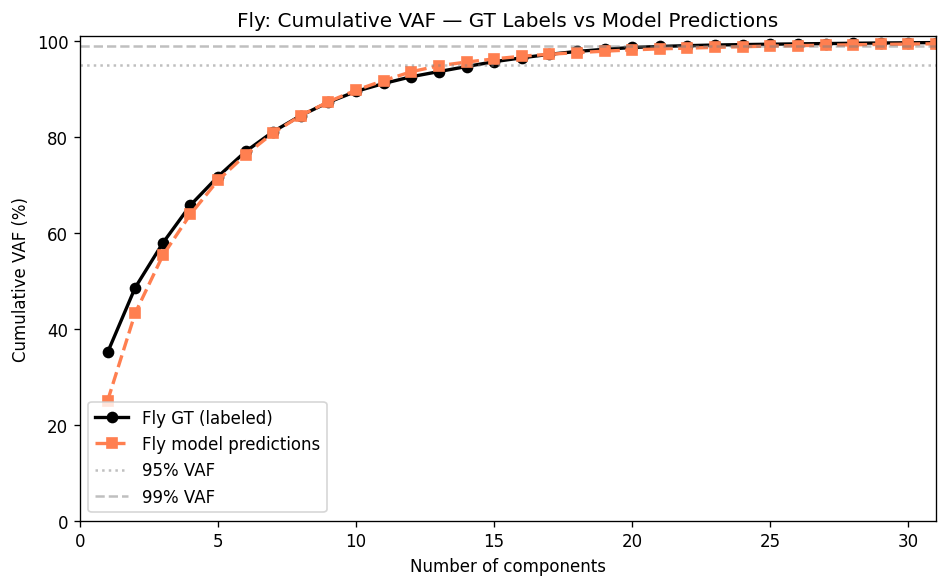

In [28]:
# ============================================================
# Fly GT (labeled data) — Cumulative VAF analysis
# ============================================================
import numpy as np
import pandas as pd
import os
import re
from omegaconf import OmegaConf
from lightning_pose.data.cameras import CameraGroup

# --- Config ---
data_dir = '/teamspace/studios/data/fly-anipose'
config_file = '/teamspace/studios/this_studio/lp3d-analysis/configs/config_fly-anipose.yaml'
views = ['Cam-A', 'Cam-B', 'Cam-C', 'Cam-D', 'Cam-E', 'Cam-F']

cfg = OmegaConf.load(config_file)
keypoint_names = list(cfg.data.keypoint_names)
n_keypoints = len(keypoint_names)

# --- Load labeled (GT) 2D data from CollectedData CSVs ---
gt_dfs = {}
for view in views:
    csv_path = os.path.join(data_dir, f'CollectedData_{view}.csv')
    df = pd.read_csv(csv_path, index_col=0, header=[0, 1, 2])
    gt_dfs[view] = df
    print(f"  {view}: {df.shape[0]} rows")
    print(f"    Example index: {df.index[0]}")

# --- Parse the index to extract a view-independent "frame ID" ---
# Index looks like: labeled-data/05272019_fly4_0_R1C24_Cam-A_rot-ccw-0.06_sec/img00000123.png
# We need to strip out the view name to get a common key across views.
def strip_view_from_index(idx, view):
    """Remove the view name from the index to get a session+frame key."""
    return idx.replace(f'_{view}_', '_VIEWPLACEHOLDER_').replace(f'_{view}/', '_VIEWPLACEHOLDER/')

# Build a mapping: common_key -> {view: original_index}
from collections import defaultdict
frame_map = defaultdict(dict)  # common_key -> {view: original_idx}

for view in views:
    df = gt_dfs[view]
    for idx in df.index:
        common_key = strip_view_from_index(idx, view)
        frame_map[common_key][view] = idx

# Keep only frames present in ALL views
common_keys = [k for k, v in frame_map.items() if len(v) == len(views)]
common_keys.sort()
print(f"\nFrames common across all {len(views)} views: {len(common_keys)}")

# --- Parse session name from common_key for calibration lookup ---
# common_key: labeled-data/05272019_fly4_0_R1C24_VIEWPLACEHOLDER_rot-ccw-0.06_sec/img00000123.png
# The session name (for calibration) is the directory name with VIEWPLACEHOLDER removed
# Original anipose session: e.g. "05272019_fly4_0_R1C24_rot-ccw-0.06_sec"

def extract_session_from_key(common_key):
    """Extract the session name from the common key."""
    # Get the directory part: "05272019_fly4_0_R1C24_VIEWPLACEHOLDER_rot-ccw-0.06_sec"
    dir_part = common_key.split('/')[1]
    # Remove the placeholder
    session = dir_part.replace('_VIEWPLACEHOLDER_', '_').replace('_VIEWPLACEHOLDER', '')
    return session

# --- Load calibrations.csv to map sessions to .toml files ---
calib_csv_path = os.path.join(data_dir, 'calibrations.csv')
calib_df = pd.read_csv(calib_csv_path)
print(f"\ncalibrations.csv columns: {list(calib_df.columns)}")
print(f"calibrations.csv shape: {calib_df.shape}")
print(f"First few rows:\n{calib_df.head()}")

# Build session -> toml path mapping
# The calibrations.csv has columns like '' (image path) and 'file' (calibration path)
# We need to extract session name from the image paths
session_to_calib = {}
for _, row in calib_df.iterrows():
    img_path = row.iloc[0]  # first column is the image path
    calib_file = row.iloc[1]  # second column is the calibration file
    # Extract session: strip view name and get directory
    dir_part = img_path.split('/')[1] if '/' in img_path else img_path
    # Remove all view names to get base session
    session = dir_part
    for view in views:
        session = session.replace(f'_{view}_', '_').replace(f'_{view}', '')
    if session not in session_to_calib:
        session_to_calib[session] = os.path.join(data_dir, calib_file)

print(f"\nFound {len(session_to_calib)} unique sessions with calibrations:")
for s, c in session_to_calib.items():
    print(f"  {s} -> {c}")

# --- Group common_keys by session ---
session_groups = defaultdict(list)
for i, key in enumerate(common_keys):
    session = extract_session_from_key(key)
    session_groups[session].append((i, key))

print(f"\nFrames per session:")
for session, items in session_groups.items():
    print(f"  {session}: {len(items)} frames")

# --- Triangulate per session ---
pts_3d_gt = np.full((len(common_keys), n_keypoints, 3), np.nan)

for session, items in session_groups.items():
    # Load calibration for this session
    if session not in session_to_calib:
        # Try to find calibration in calibrations/ directory directly
        calib_path = os.path.join(data_dir, 'calibrations', f'{session}.toml')
        if not os.path.exists(calib_path):
            print(f"  WARNING: No calibration found for session '{session}', skipping {len(items)} frames")
            continue
    else:
        calib_path = session_to_calib[session]
    
    print(f"\n  Triangulating session: {session} ({len(items)} frames)")
    print(f"    Calibration: {calib_path}")
    camgroup = CameraGroup.load(calib_path)
    calib_cam_names = [c.name for c in camgroup.cameras]
    
    for frame_idx, common_key in items:
        view_indices = frame_map[common_key]
        
        # Build 2D points: (n_cams, n_keypoints, 2)
        pts_2d = np.full((len(calib_cam_names), n_keypoints, 2), np.nan)
        
        for cam_idx, cam_name in enumerate(calib_cam_names):
            if cam_name not in view_indices:
                continue
            orig_idx = view_indices[cam_name]
            df = gt_dfs[cam_name]
            row = df.loc[orig_idx]
            
            for k_idx, kp in enumerate(keypoint_names):
                try:
                    x = row.xs(kp, level='bodyparts').xs('x', level='coords')
                    y = row.xs(kp, level='bodyparts').xs('y', level='coords')
                    pts_2d[cam_idx, k_idx, 0] = float(x.values[0]) if hasattr(x, 'values') else float(x)
                    pts_2d[cam_idx, k_idx, 1] = float(y.values[0]) if hasattr(y, 'values') else float(y)
                except (KeyError, IndexError):
                    pass
        
        # Triangulate
        try:
            pts_3d_gt[frame_idx] = camgroup.triangulate_fast(pts_2d, undistort=True)
        except Exception as e:
            print(f"    Triangulation failed for frame {frame_idx}: {e}")

n_valid = (~np.isnan(pts_3d_gt).any(axis=(1, 2))).sum()
print(f"\nGT 3D shape: {pts_3d_gt.shape}")
print(f"Valid frames (no NaN): {n_valid} / {len(common_keys)}")

# --- SVD analysis ---
U_gt, S_gt, Vt_gt, data_centered_gt, valid_mask_gt, mean_gt = compute_svd_analysis(pts_3d_gt)
var_explained_gt = (S_gt ** 2) / np.sum(S_gt ** 2) * 100
cum_var_gt = np.cumsum(var_explained_gt)

n_95_gt = np.argmax(cum_var_gt >= 95) + 1
n_99_gt = np.argmax(cum_var_gt >= 99) + 1
print(f"\nGT — Components for 95% VAF: {n_95_gt}")
print(f"GT — Components for 99% VAF: {n_99_gt}")

# --- Plot: Cumulative VAF comparison ---
fig, ax = plt.subplots(figsize=(8, 5))

n_comp = len(cum_var_gt)
ax.plot(range(1, n_comp + 1), cum_var_gt, 'o-', color='black', label='Fly GT (labeled)', linewidth=2)

if 'fly-anipose' in all_results:
    session_key = list(all_results['fly-anipose'].keys())[0]
    cum_var_model = all_results['fly-anipose'][session_key]['cum_var']
    ax.plot(range(1, len(cum_var_model) + 1), cum_var_model, 's--', color='coral',
            label='Fly model predictions', linewidth=2)

ax.axhline(95, color='gray', linestyle=':', alpha=0.5, label='95% VAF')
ax.axhline(99, color='gray', linestyle='--', alpha=0.5, label='99% VAF')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative VAF (%)')
ax.set_title('Fly: Cumulative VAF — GT Labels vs Model Predictions')
ax.legend()
ax.set_xlim(0, min(n_comp, 30) + 1)
ax.set_ylim(0, 101)
plt.tight_layout()
plt.show()